<a href="https://colab.research.google.com/github/KirtiSinghal08/DiabetesIQ/blob/main/ML_PROJECT_DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Diabetes Prediction – Machine Learning Project
**ML Project |ISHITA BABBAR(2K24CSUN01165) | KIRTI SINGHAL(2K24CSUN01175)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


##  Data Handling and Preprocessing

In [ ]:
df = pd.read_csv("diabetes.csv")
print("First 5 rows:\n", df.head())


First 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


**1 = DIABETIC, 0 = NON-DIABETIC**

In [ ]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
print("\nDataset Info:\n")
print(df.info())



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


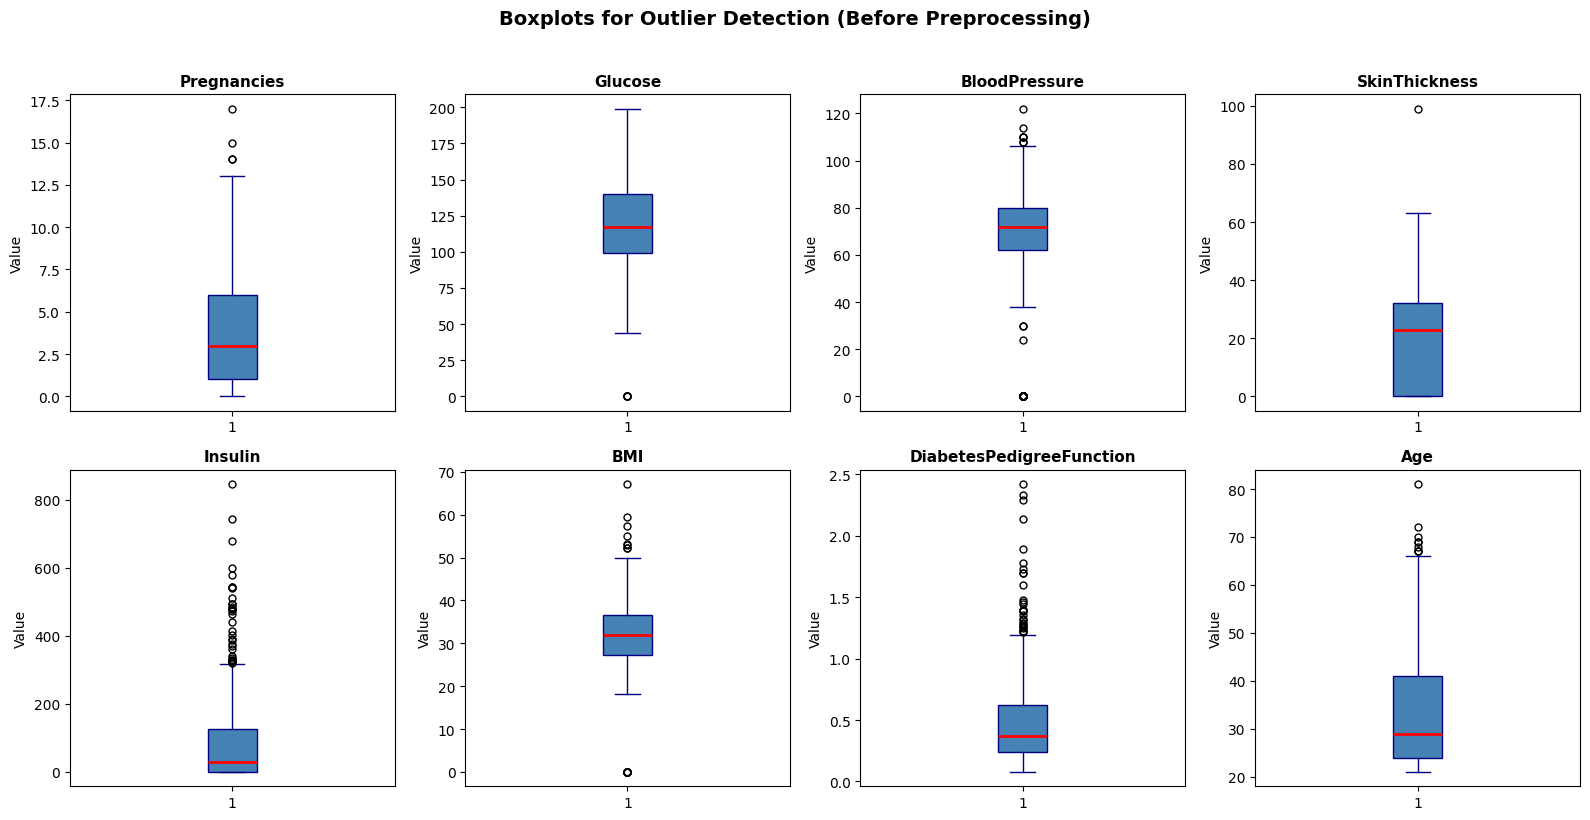

Outlier count per feature (IQR method):
  Pregnancies                 : 4 outliers
  Glucose                     : 5 outliers
  BloodPressure               : 45 outliers
  SkinThickness               : 1 outliers
  Insulin                     : 34 outliers
  BMI                         : 19 outliers
  DiabetesPedigreeFunction    : 29 outliers
  Age                         : 9 outliers


In [ ]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].boxplot(df[feature].dropna(), patch_artist=True,
                   boxprops=dict(facecolor="steelblue", color="navy"),
                   medianprops=dict(color="red", linewidth=2),
                   whiskerprops=dict(color="navy"),
                   capprops=dict(color="navy"),
                   flierprops=dict(marker="o", color="orange", markersize=5))
    axes[i].set_title(feature, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Value")

plt.suptitle("Boxplots for Outlier Detection (Before Preprocessing)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Outlier count per feature (IQR method):")
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[feature] < Q1 - 1.5 * IQR) | (df[feature] > Q3 + 1.5 * IQR)]
    print(f"  {feature:<28}: {len(outliers)} outliers")

DATA PREPROCESSING

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero values BEFORE preprocessing:\n")
for col in cols:
    print(col, ":", (df[col] == 0).sum())


Zero values BEFORE preprocessing:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [ ]:
df[cols] = df[cols].replace(0, np.nan)

print("\nMissing values AFTER replacing 0 with NaN:\n")
print(df.isnull().sum())



Missing values AFTER replacing 0 with NaN:

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
df.fillna(df.median(numeric_only=True), inplace=True)

print("\nMissing values AFTER filling:\n")
print(df.isnull().sum())



Missing values AFTER filling:

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Train/Test Split

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


##  Logistic Regression
### Model Development and Training

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n--- Logistic Regression (Base Model) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))



--- Logistic Regression (Base Model) ---
Accuracy: 0.7532467532467533
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix:
 [[82 17]
 [21 34]]


### Hyperparameter Tuning – Logistic Regression

In [ ]:
param_grid_lr = {'C': [0.1, 1.0, 10.0]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)

Best LR params: {'C': 1.0}


In [ ]:
lr_results = pd.DataFrame(grid_lr.cv_results_)
lr_results = lr_results[['param_C', 'mean_test_score']]
lr_results.columns = ['C', 'Accuracy']

lr_results['Trial ID'] = ['LR_' + str(i+1).zfill(2) for i in range(len(lr_results))]

best_lr_score = lr_results['Accuracy'].max()
lr_results['Status'] = lr_results['Accuracy'].apply(
    lambda x: "Best" if x == best_lr_score else "Better" if x > best_lr_score - 0.01 else "Baseline"
)

lr_results = lr_results[['Trial ID', 'C', 'Accuracy', 'Status']]

print("\n===== Logistic Regression Trials =====")
print(lr_results)



===== Logistic Regression Trials =====
  Trial ID     C  Accuracy  Status
0    LR_01   0.1  0.767133  Better
1    LR_02   1.0  0.768772    Best
2    LR_03  10.0  0.767146  Better


##  Random Forest
### Model Development and Training

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n--- Random Forest (Base Model) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



--- Random Forest (Base Model) ---
Accuracy: 0.7337662337662337
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

Confusion Matrix:
 [[78 21]
 [20 35]]


### Hyperparameter Tuning – Random Forest

In [ ]:
# FIX: GridSearchCV for Random Forest was missing in the original notebook
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)

print("Best RF params:", grid_rf.best_params_)


Best RF params: {'max_depth': None, 'n_estimators': 100}


In [ ]:
rf_results = pd.DataFrame(grid_rf.cv_results_)
rf_results = rf_results[['param_n_estimators', 'param_max_depth', 'mean_test_score']]
rf_results.columns = ['n_estimators', 'max_depth', 'Accuracy']

rf_results['Trial ID'] = ['RF_' + str(i+1).zfill(2) for i in range(len(rf_results))]

best_rf_score = rf_results['Accuracy'].max()
rf_results['Status'] = rf_results['Accuracy'].apply(
    lambda x: "Best" if x == best_rf_score else "Better" if x > best_rf_score - 0.01 else "Baseline"
)

rf_results = rf_results[['Trial ID', 'n_estimators', 'max_depth', 'Accuracy', 'Status']]

print("\n===== Random Forest Trials =====")
print(rf_results)



===== Random Forest Trials =====
  Trial ID  n_estimators max_depth  Accuracy    Status
0    RF_01           100      None  0.778529      Best
1    RF_02           200      None  0.767133  Baseline
2    RF_03           100        10  0.752459  Baseline
3    RF_04           200        10  0.762215  Baseline
4    RF_05           100        20  0.775277    Better
5    RF_06           200        20  0.768759    Better


## 📈 Evaluation and Interpretation

In [ ]:
best_lr_model = grid_lr.best_estimator_
best_rf_model = grid_rf.best_estimator_

y_pred_lr = best_lr_model.predict(X_test)
y_pred_rf = best_rf_model.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("\n=== MODEL COMPARISON (Tuned Models) ===")
print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)



=== MODEL COMPARISON (Tuned Models) ===
Logistic Regression Accuracy: 0.7532467532467533
Random Forest Accuracy: 0.7337662337662337


### Confusion Matrices

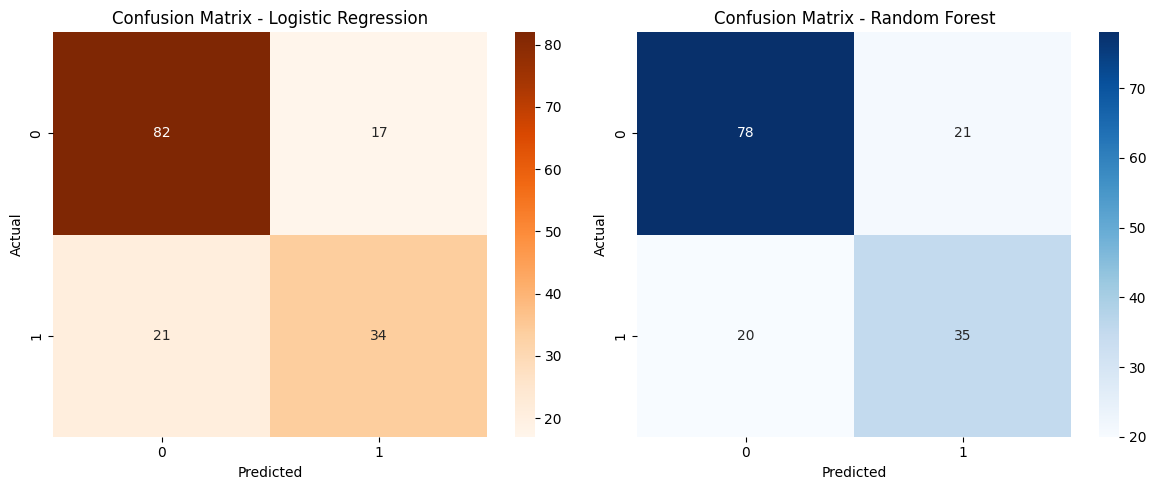

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[0])
axes[0].set_title("Confusion Matrix - Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("Confusion Matrix - Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### Accuracy Comparison

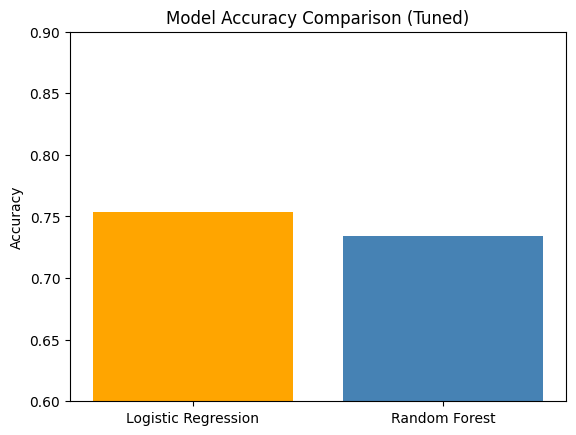

In [ ]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies, color=['orange', 'steelblue'])
plt.title("Model Accuracy Comparison (Tuned)")
plt.ylabel("Accuracy")
plt.ylim(0.6, 0.9)
plt.show()


### ROC Curves

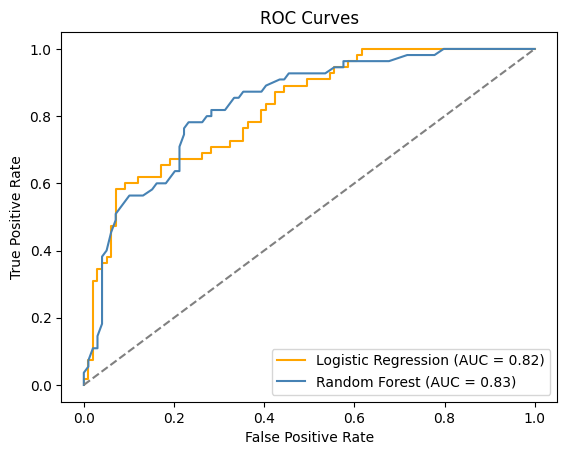

In [ ]:
y_prob_lr = best_lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (AUC = " + str(round(roc_auc_lr, 2)) + ")", color='orange')
plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = " + str(round(roc_auc_rf, 2)) + ")", color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### Feature Importance (Random Forest)

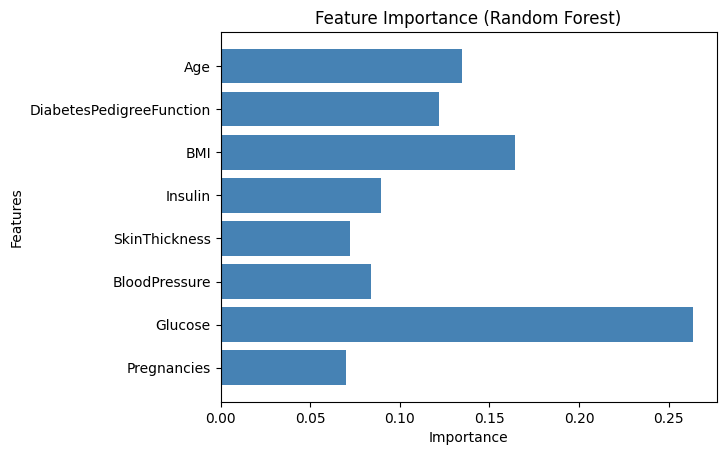

In [ ]:
importances = best_rf_model.feature_importances_

plt.figure()
plt.barh(X.columns, importances, color='steelblue')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


##  Final Leaderboard

In [ ]:
leaderboard = pd.DataFrame({
    "Model": ["Random Forest", "Logistic Regression"],
    "Hyperparameters": [
        f"n={grid_rf.best_params_['n_estimators']}, depth={grid_rf.best_params_['max_depth']}",
        f"C={grid_lr.best_params_['C']}"
    ],
    "Accuracy": [f"{rf_acc*100:.2f}%", f"{lr_acc*100:.2f}%"],
    "Error": [round(1-rf_acc, 3), round(1-lr_acc, 3)]
})

print(leaderboard)

                 Model    Hyperparameters Accuracy  Error
0        Random Forest  n=100, depth=None   73.38%  0.266
1  Logistic Regression              C=1.0   75.32%  0.247


## Conclusion and Learning Outcomes

In [ ]:
print("\nConclusion:")
print("Logistic Regression performed better than Random Forest for this dataset.")
print("It achieved higher accuracy, indicating the data follows a more linear pattern.")


Conclusion:
Logistic Regression performed better than Random Forest for this dataset.
It achieved higher accuracy, indicating the data follows a more linear pattern.
